In [1]:
import pandas as pd
dataset=pd.read_csv("50_Startups.csv")


In [2]:
dataset=pd.get_dummies(dataset,drop_first=True)
dataset

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0
5,131876.90,99814.71,362861.36,156991.12,0,1
6,134615.46,147198.87,127716.82,156122.51,0,0
7,130298.13,145530.06,323876.68,155752.60,1,0
8,120542.52,148718.95,311613.29,152211.77,0,1
9,123334.88,108679.17,304981.62,149759.96,0,0


In [3]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [4]:
independent=dataset[['R&D Spend', 'Administration', 'Marketing Spend','State_Florida', 'State_New York']]
dependent=dataset[['Profit']]

In [5]:
## To validate model performance we use Homo/Hetroscadisticity
## To arrive at Homo/Hetroscadisticity we need residuals and predicted values, 
## for which we use statsmodels.OLS(OrdinaryLeastSquares)

In [6]:
import statsmodels.api as sm
x=independent
x=sm.add_constant(x)

In [7]:
y=dependent
model=sm.OLS(y,x).fit()

In [8]:
y_pred=model.predict(x)

In [9]:
print(model.resid)  ## print residual

0      -128.741364
1      2720.739894
2      8774.203265
3      9317.013809
4     -6089.193818
5     -6482.687120
6     -1976.782788
7     -4403.044650
8       577.026673
9     -5069.702528
10    10457.307408
11     8730.799217
12    12302.602193
13     6876.101014
14   -17091.732777
15   -16226.595515
16    10138.855472
17    -4715.039933
18    -4882.825743
19     7182.671590
20     1903.295561
21    -5888.485088
22    -4481.055137
23    -1389.806104
24    -4742.333453
25     5204.071081
26    -5031.761169
27    -9271.494028
28     1463.792613
29     -716.402030
30      308.579462
31     -133.736321
32    -1560.396604
33    -1282.438947
34     7738.095839
35     6059.500395
36    15285.097137
37      371.437779
38    11622.538393
39    -2679.216039
40     3477.163825
41     2842.518952
42      922.496288
43     9658.711782
44      615.182788
45    17337.715291
46    -6782.242680
47    -3908.502003
48   -13449.663082
49   -33503.638791
dtype: float64


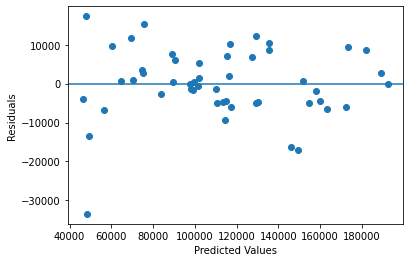

In [10]:
##Residual plot

import matplotlib.pyplot as plt

plt.scatter(y_pred, model.resid)

plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()

In [ ]:
## From the above plot, we see Homoscedasticty which says the model is good.

In [11]:
## The Purpose of Homo/Hetroscedasticity is to verify whether the regression model assumptions 
## are valid and whether the model is statistically reliable(validate the model performance).Homoscedasticity and 
## Heteroscedasticity are used to check how the residuals or errors behave in a regression model
##(Residual=Actual−Predicted).

##Among Homo/Hetro, Homoscedasticity is better because of stable model behavior,reliable regression coefficients and 
## accurate confidence intervals where Heteroscedasticity can lead to unstable coefficients and unreliable inference.